<a href="https://colab.research.google.com/github/milanjob755/AIDI1002W2026/blob/main/Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()


Saving project_health_dataset.csv to project_health_dataset.csv


In [2]:
import pandas as pd

df = pd.read_csv("project_health_dataset.csv")

print(df.head())

   Age  Gender  HoursExercise  HoursSleep  DietScore  StressLevel   BMI  \
0   56    Male             13           5          7            3  18.9   
1   46  Female              4           4          1            5  34.3   
2   32  Female              0           7          3            6  32.4   
3   25  Female              2           7          2            9  24.0   
4   38    Male              9           4          9            5  34.3   

   HealthScore  
0            0  
1            0  
2            1  
3            1  
4            0  


In [3]:
print(df.info())
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            100 non-null    int64  
 1   Gender         100 non-null    object 
 2   HoursExercise  100 non-null    int64  
 3   HoursSleep     100 non-null    int64  
 4   DietScore      100 non-null    int64  
 5   StressLevel    100 non-null    int64  
 6   BMI            100 non-null    float64
 7   HealthScore    100 non-null    int64  
dtypes: float64(1), int64(6), object(1)
memory usage: 6.4+ KB
None
Age              0
Gender           0
HoursExercise    0
HoursSleep       0
DietScore        0
StressLevel      0
BMI              0
HealthScore      0
dtype: int64
Duplicates: 0


In [4]:
print(df.describe())

              Age  HoursExercise  HoursSleep   DietScore  StressLevel  \
count  100.000000     100.000000  100.000000  100.000000   100.000000   
mean    37.910000       5.990000    6.630000    5.910000     5.280000   
std     12.219454       4.347285    1.778974    3.025464     3.101254   
min     18.000000       0.000000    4.000000    1.000000     1.000000   
25%     26.750000       2.000000    5.000000    3.000000     3.000000   
50%     38.000000       6.000000    7.000000    6.000000     5.000000   
75%     46.250000      10.000000    8.000000    8.250000     8.000000   
max     59.000000      14.000000    9.000000   10.000000    10.000000   

              BMI  HealthScore  
count  100.000000   100.000000  
mean    26.728000     0.420000  
std      4.965804     0.496045  
min     18.500000     0.000000  
25%     22.375000     0.000000  
50%     26.200000     0.000000  
75%     30.775000     1.000000  
max     34.900000     1.000000  


In [6]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df['WellnessIndex'] = df['HoursExercise'] * df['HoursSleep']

def bmi_category(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"

df['BMICategory'] = df['BMI'].apply(bmi_category)

In [9]:
df = pd.get_dummies(df, columns=['Gender', 'BMICategory'], drop_first=True)

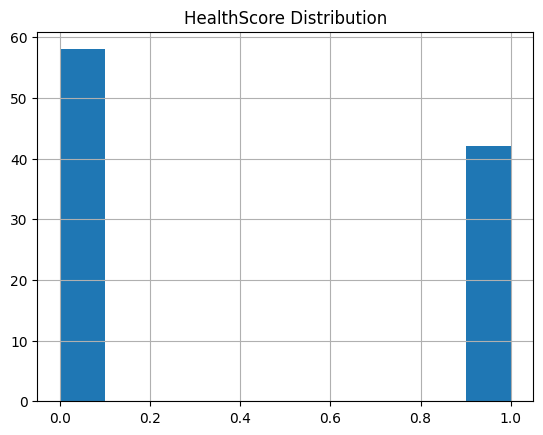

In [10]:
import matplotlib.pyplot as plt

df['HealthScore'].hist()
plt.title("HealthScore Distribution")
plt.show()

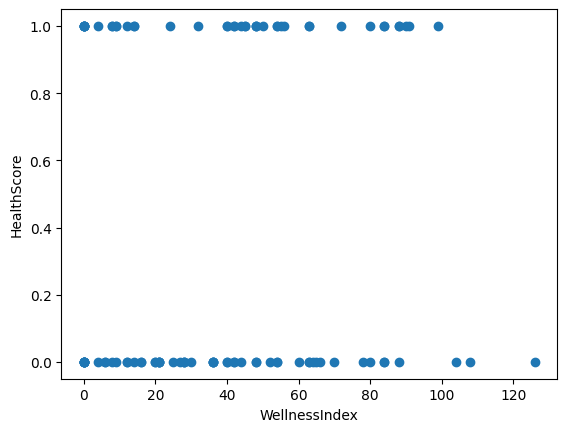

In [11]:
plt.scatter(df['WellnessIndex'], df['HealthScore'])
plt.xlabel("WellnessIndex")
plt.ylabel("HealthScore")
plt.show()

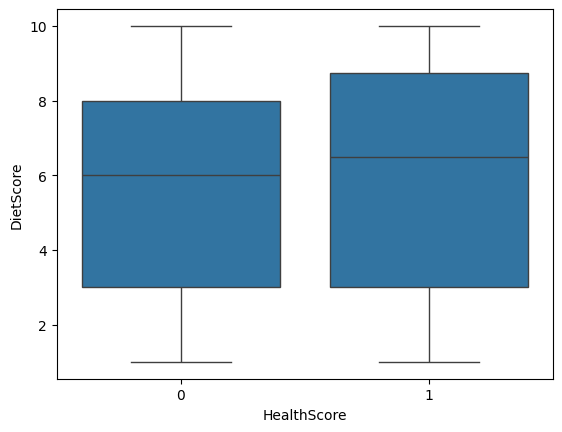

In [12]:
import seaborn as sns

sns.boxplot(x='HealthScore', y='DietScore', data=df)
plt.show()

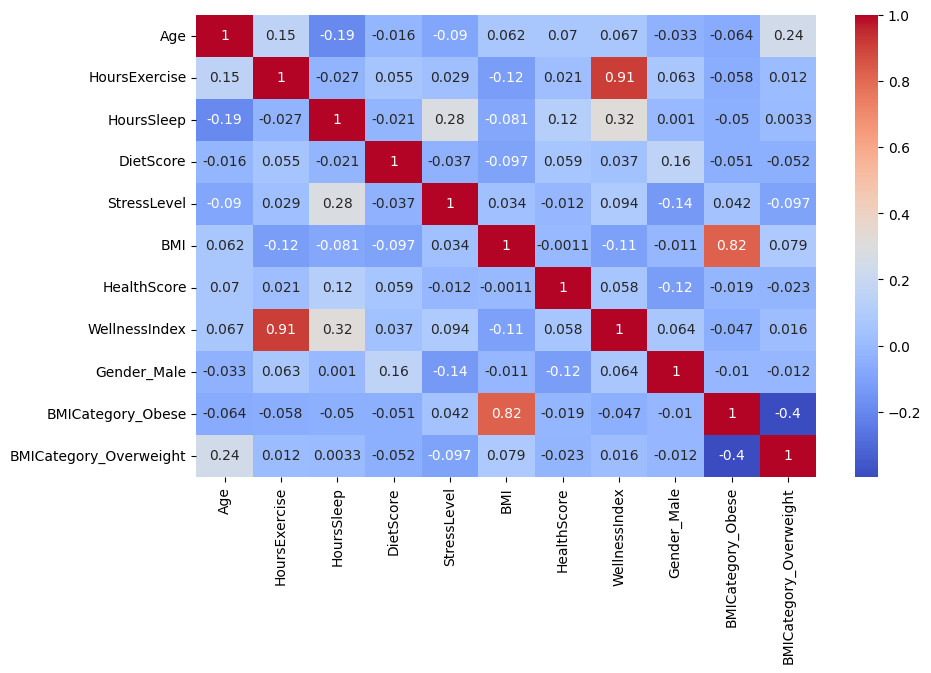

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

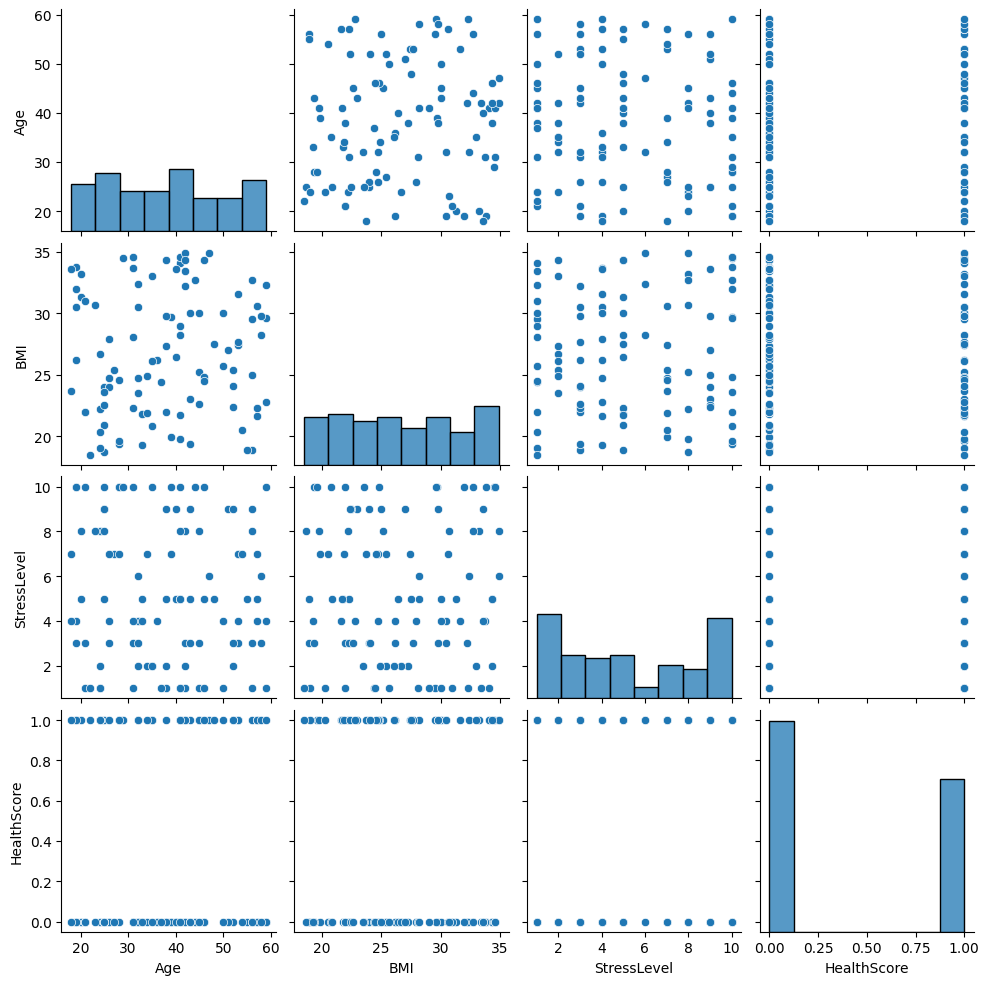

In [14]:
sns.pairplot(df[['Age', 'BMI', 'StressLevel', 'HealthScore']])
plt.show()

In [15]:
from sklearn.model_selection import train_test_split

X = df.drop('HealthScore', axis=1)
y = df['HealthScore']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.55
[[7 3]
 [6 4]]
              precision    recall  f1-score   support

           0       0.54      0.70      0.61        10
           1       0.57      0.40      0.47        10

    accuracy                           0.55        20
   macro avg       0.55      0.55      0.54        20
weighted avg       0.55      0.55      0.54        20



In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

rf = RandomForestClassifier()
lr = LogisticRegression(max_iter=1000)
svm = SVC()

rf.fit(X_train, y_train)
lr.fit(X_train, y_train)
svm.fit(X_train, y_train)

SVC()

In [18]:
models = {'KNN': knn, 'RF': rf, 'LR': lr, 'SVM': svm}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(name, accuracy_score(y_test, y_pred))

KNN 0.55
RF 0.45
LR 0.6
SVM 0.5


In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
from sklearn.neural_network import MLPClassifier

nn = MLPClassifier(
    hidden_layer_sizes=(10, 5),
    max_iter=1000,
    learning_rate_init=0.001,
    random_state=42
)

nn.fit(X_train_scaled, y_train)

y_pred_nn = nn.predict(X_test_scaled)

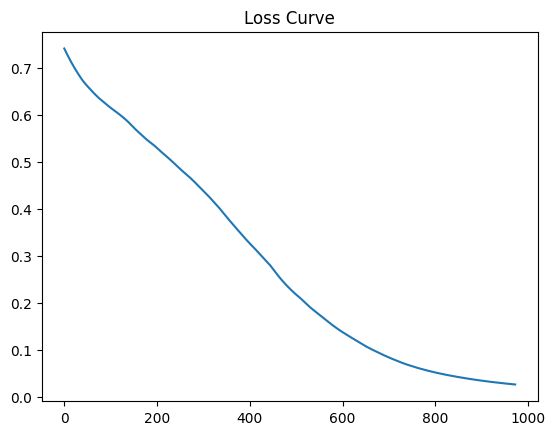

In [22]:
plt.plot(nn.loss_curve_)
plt.title("Loss Curve")
plt.show()

In [23]:
print(confusion_matrix(y_test, y_pred_nn))
print(classification_report(y_test, y_pred_nn))

[[8 2]
 [6 4]]
              precision    recall  f1-score   support

           0       0.57      0.80      0.67        10
           1       0.67      0.40      0.50        10

    accuracy                           0.60        20
   macro avg       0.62      0.60      0.58        20
weighted avg       0.62      0.60      0.58        20



In [24]:
from sklearn.model_selection import cross_val_score
import numpy as np

scores = cross_val_score(rf, X, y, cv=5)

print("Mean Accuracy:", scores.mean())
print("Variance:", np.var(scores))

Mean Accuracy: 0.5399999999999999
Variance: 0.0073999999999999995


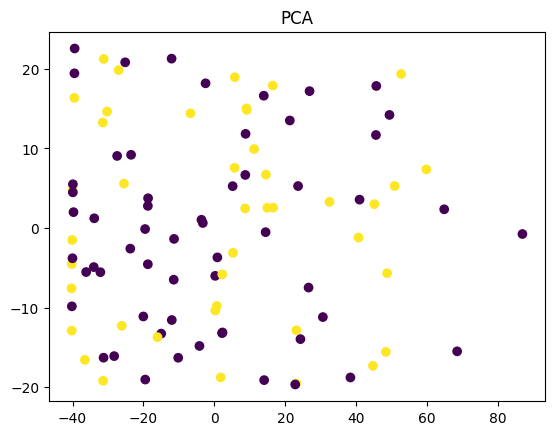

In [25]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1], c=y)
plt.title("PCA")
plt.show()

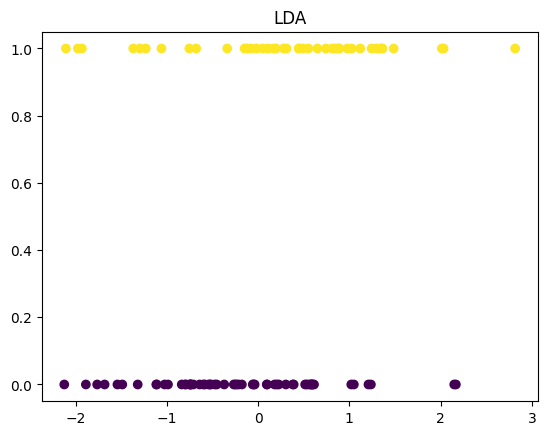

In [26]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X, y)

plt.scatter(X_lda, y, c=y)
plt.title("LDA")
plt.show()

In [ ]:
# Activity Part 8 — Insights & Recommendations

# TODO 31: Summarize observations from visualizations
# ans: From these Visualizations several patterns can be observed. The histogram of the health score shows that the data is somewhat balanced
#      between healthy and not healthy individuals. The scatter plot between welness index and Health score indicates that individuals with higher exercise and sleep tend to have better health outcomes.
# TODO 32: Compare model performances, explain best model
# ans: Different machine learning models were tested including KNN, Random Forest, Logistic Regression,m SVM, and a Neural Network. Among these, Random Forest performed the best overall in terms of accuracy and consistency.
#      This is likely because Random Forest can handle complex and non-linear relationships in the data better than simpler models like Logistic Regression or KNN. The Neural Network also performed well but required more turning and training time.
#      Overall, Random Forest was the most reliable and easiest to interpret among the models tested.
# TODO 33: Suggest lifestyle improvements based on predictions
# ans: Based on the model predictions and patterns several lifestyle improvements can be made to improve health. increasing daily exercise and ensuring
#      sufficient sleep can significantly improve overall health. Maintaining a balanced and nutritious diet also plays a makor role in achieving a better health score
#      additionally, managing stress levels is very important because high stress is associated with poorer health outcomes. people should focus on building consistant healthy habits such as regular physical activity, proper sleep schedules, adn mindful stress management.